# Araba Fiyatları (Car Prices)

🎯 Bu challenge’ın amacı, bir dataset hazırlamak ve şimdiye kadar öğrendiğiniz bazı feature selection tekniklerini uygulamaktır.

🚗 Arabalarla ilgili bir veri setiyle çalışıyoruz ve bir arabanın pahalı mı yoksa ucuz mu olduğunu tahmin etmek istiyoruz.

In [45]:
# Data manipulation
import numpy as np
import pandas as pd
# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Sayısal bir özelliğin normal dağılım gösterip göstermediğini kontrol etme
from statsmodels.graphics.gofplots import qqplot


In [46]:
url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_dataset.csv"

❓ CSV dosyasını `df` adlı bir veri çerçevesine yükleyin.

In [47]:
df = pd.read_csv(url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   enginelocation  195 non-null    object 
 2   carwidth        203 non-null    object 
 3   curbweight      205 non-null    int64  
 4   enginetype      205 non-null    object 
 5   cylindernumber  205 non-null    object 
 6   stroke          205 non-null    float64
 7   peakrpm         205 non-null    int64  
 8   price           205 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 14.5+ KB


In [48]:
# Sonuç kontrolü: Eksik veri kaldı mı?
print(df.isnull().sum())

aspiration         0
enginelocation    10
carwidth           2
curbweight         0
enginetype         0
cylindernumber     0
stroke             0
peakrpm            0
price              0
dtype: int64


ℹ️ Dataset’in açıklaması [burada](https://drive.google.com/file/d/1ADSyjWfRGYqdXwCCN4PPC7PjQeMZ-ap-/view?usp=sharing ) mevcuttur. Egzersiz boyunca buna mutlaka referans verin.

## (1) Yinelenenler (Duplicates)

❓ Varsa, veri kümesinden yinelenenleri kaldırın. ❓

*Veri çerçevesini `df`* üzerine yazın.

In [49]:
# 1. Kaç tane tekrarlayan satır olduğunu gör
duplicate_count = df.duplicated().sum()
print(f"Toplam tekrarlayan satır sayısı: {duplicate_count}")

# 2. Tekrarlayan satırları sil (sadece ilkini tutar)
df = df.drop_duplicates()

# 3. Sonuç kontrolü
print(f"Temizlik sonrası veri seti boyutu: {df.shape}")

Toplam tekrarlayan satır sayısı: 14
Temizlik sonrası veri seti boyutu: (191, 9)


In [50]:
# Tekrarlayanları sil ve satır numaralarını (0, 1, 2...) diye yeniden düzenle
df = df.drop_duplicates().reset_index(drop=True)

## (2)  Eksik değerler (Missing values)

❓ Eksik değerleri bulun ve bunları ya `strategy = "most frequent"` (kategorik değişkenler için) ya da `strategy = "median"` (sayısal değişkenler için) kullanarak doldurun ❓

In [51]:
import pandas as pd
from sklearn.impute import SimpleImputer

# 1. Sayısal olması gereken sütunları sayıya çevirelim
# 'coerce' parametresi, eğer sayıya çevrilemeyen garip bir karakter varsa orayı NaN yapar
df['carwidth'] = pd.to_numeric(df['carwidth'], errors='coerce')
df['curbweight'] = pd.to_numeric(df['curbweight'], errors='coerce')

# 2. Şimdi sütun tiplerini tekrar ayıralım
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# 3. Sayısal sütunlar için "median" stratejisi
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# 4. Kategorik sütunlar için "most_frequent" stratejisi
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("İşlem başarıyla tamamlandı. Eksik veri sayısı:", df.isnull().sum().sum())

İşlem başarıyla tamamlandı. Eksik veri sayısı: 0


### `carwidth`

<details>
    <summary> 💡 <i>İpucu</i> </summary>
    <br>
    ℹ️ <code>carwidth</code> sütununda eksik değerler birden fazla şekilde temsil edilmektedir. Bazıları <code>np.nan</code>, bazıları ise <code>*</code> olarak yer alır. Bunlar tespit edildikten sonra, eksik değerler verinin %30’undan daha azını oluşturduğu için medyan değerle doldurulabilir.
</details>

In [52]:
df['carwidth'].describe()

count    191.000000
mean      65.961257
std        2.096279
min       60.300000
25%       64.200000
50%       65.500000
75%       66.900000
max       72.300000
Name: carwidth, dtype: float64

### `enginelocation`

<details>
    <summary>💡 <i>İpucu</i> </summary>
    <br>
    ℹ️ <code>enginelocation</code> kategorik bir feature olduğundan ve kategorilerin büyük çoğunluğu <code>front</code> olduğu için, en sık görülen değerle doldurun.
</details>

In [53]:
df['enginelocation'].describe()

count       191
unique        2
top       front
freq        189
Name: enginelocation, dtype: object

🧪 **Kodunu test et**

In [54]:
from nbresult import ChallengeResult

result = ChallengeResult('missing_values',
                         dataset = df)
result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- c:\Users\nidat\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\nidat\.vscode\S16D2-S-Data-car-prices\tests
plugins: anyio-4.2.0
collecting ... collected 2 items

test_missing_values.py::TestMissing_values::test_carwidth PASSED         [ 50%]
test_missing_values.py::TestMissing_values::test_engine_location PASSED  [100%]

============================== 2 passed in 2.42s ==============================


💯 You can commit your code:

git add tests/missing_values.pickle

git commit -m 'Completed missing_values step'

git push origin master



## (3) Sayısal özelliklerin ölçeklendirilmesi (Scaling the numerical features)

In [55]:
# Hatırlatma olarak, DataFrame hakkında bazı bilgiler
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      191 non-null    object 
 1   enginelocation  191 non-null    object 
 2   carwidth        191 non-null    float64
 3   curbweight      191 non-null    float64
 4   enginetype      191 non-null    object 
 5   cylindernumber  191 non-null    object 
 6   stroke          191 non-null    float64
 7   peakrpm         191 non-null    float64
 8   price           191 non-null    object 
dtypes: float64(4), object(5)
memory usage: 13.6+ KB


In [56]:
# Ve işte ölçeklendirmemiz gereken veri kümesinin sayısal özellikleri
numerical_features = df.select_dtypes(exclude=['object']).columns
numerical_features

Index(['carwidth', 'curbweight', 'stroke', 'peakrpm'], dtype='object')

❓ **Soru: Sayısal feature’ların ölçeklenmesi** ❓

Sayısal feature’ları aykırı değerler (outliers) ve dağılımları açısından inceleyin ve duruma göre aşağıdaki yöntemleri uygulayın:
- Robust Scaler
- Standard Scaler

Dönüştürülmüş değerlerle orijinal sütunları değiştirin.

### `peakrpm` , `carwidth` , & `stroke`

<details>
    <summary>💡 <i>İpucu</i> </summary>

    
ℹ️ <code>peakrpm</code>, <code>carwidth</code> ve <code>stroke</code> normal dağılıma sahiptir ancak aynı zamanda bazı aykırı değerler (outlier) içerir. Bu nedenle `RobustScaler()` kullanılması tavsiye edilir.
</details>

In [57]:
from sklearn.preprocessing import RobustScaler

# 1. İşlem yapacağın sütunları belirle
target_cols = ['peakrpm', 'carwidth', 'stroke']

# 2. Önce bu sütunları sayısal tipe (float) çevirelim
for col in target_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. RobustScaler nesnesini tanımla
scaler = RobustScaler()

# 4. Sadece bu üç sütunu ölçeklendir ve orijinal sütunları değiştir
df[target_cols] = scaler.fit_transform(df[target_cols])

# 5. Kontrol edelim
print(df[target_cols].head())

    peakrpm  carwidth    stroke
0 -0.142857 -0.518519 -2.033333
1 -0.142857  0.000000  0.600000
2  0.571429  0.000000  0.366667
3  0.571429  0.333333  0.366667
4  0.571429  0.296296  0.366667


In [58]:
# SENİN KODUN BURAYA

### `curbweight`

<details>
    <summary>💡 <i>İpucu</i> </summary>
    <br>
    ℹ️ <code>curbweight</code> normal bir dağılıma sahiptir ve aykırı değer (outlier) içermez. Bu nedenle Standard Scaler ile ölçeklenebilir.
</details>

In [59]:
df['curbweight'].describe()

count     191.000000
mean     2573.204188
std       525.724187
min      1488.000000
25%      2190.500000
50%      2443.000000
75%      2964.500000
max      4066.000000
Name: curbweight, dtype: float64

In [60]:
from sklearn.preprocessing import StandardScaler

# 1. Önce curbweight sütununu sayısal tipe zorlayalım (Önlem amaçlı)
df['curbweight'] = pd.to_numeric(df['curbweight'], errors='coerce')

# 2. StandardScaler nesnesini oluşturalım
std_scaler = StandardScaler()

# 3. Sadece 'curbweight' sütununu ölçeklendir ve üzerine yazalım
df[['curbweight']] = std_scaler.fit_transform(df[['curbweight']])

# 4. Kontrol edelim (Ortalama 0'a çok yakın, std ise 1 olmalı)
print(df['curbweight'].head())
print(f"\nYeni Ortalama: {df['curbweight'].mean():.2f}")
print(f"Yeni Standart Sapma: {df['curbweight'].std():.2f}")

0   -0.048068
1    0.476395
2   -0.450474
3    0.478302
4   -0.126260
Name: curbweight, dtype: float64

Yeni Ortalama: 0.00
Yeni Standart Sapma: 1.00


🧪 **Kodunu test et**

In [61]:
from nbresult import ChallengeResult

result = ChallengeResult('scaling',
                         dataset = df
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- c:\Users\nidat\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\nidat\.vscode\S16D2-S-Data-car-prices\tests
plugins: anyio-4.2.0
collecting ... collected 4 items

test_scaling.py::TestScaling::test_carwidth PASSED                       [ 25%]
test_scaling.py::TestScaling::test_curbweight PASSED                     [ 50%]
test_scaling.py::TestScaling::test_peakrpm PASSED                        [ 75%]
test_scaling.py::TestScaling::test_stroke PASSED                         [100%]

============================== 4 passed in 1.42s ==============================


💯 You can commit your code:

git add tests/scaling.pickle

git commit -m 'Completed scaling step'

git push origin master



## (4) Kategorik özelliklerin kodlanması (Encoding the categorical features)

❓ **Soru: Kategorik değişkenlerin encode edilmesi** ❓

👇 Encode edilmesi gereken feature’ları inceleyin ve duruma göre aşağıdaki teknikleri uygulayın:

- One-hot encoding
- Manuel ordinal encoding

DataFrame içinde, orijinal feature’ları encode edilmiş versiyonlarıyla değiştirin.

### `aspiration` & `enginelocation`

<details>
    <summary>💡 <i>İpucu</i> </summary>
    <br>
    ℹ️ <code>aspiration</code> ve <code>enginelocation</code> ikili (binary) kategorik feature’lardır.
</details>

In [62]:
# binary kategorik feature'lar için manuel ordinal encoding uygun  
# 1. aspiration sütunu için eşleme (std=0, turbo=1)
# Veri setindeki yaygın kullanıma göre 'std' standarttır, 'turbo' ise ek özelliktir.
aspiration_map = {'std': 0, 'turbo': 1}
df['aspiration'] = df['aspiration'].map(aspiration_map)

# 2. enginelocation sütunu için eşleme (front=0, rear=1)
# Arabaların %99'u front (ön) motorlu olduğu için front'u 0 kabul ediyoruz.
engine_map = {'front': 0, 'rear': 1}
df['enginelocation'] = df['enginelocation'].map(engine_map)

# 3. Sonuçları kontrol edelim
print(df[['aspiration', 'enginelocation']].head())

   aspiration  enginelocation
0           0               0
1           0               0
2           0               0
3           0               0
4           0               0


### `enginetype`

<details>
    <summary>💡 <i>İpucu</i> </summary>
    <br>
    ℹ️ <code>enginetype</code> çok kategorili (multicategorical) bir feature’dır ve One-hot encoding uygulanmalıdır.
</details>

In [70]:
# 1. 'enginetype' sütununa One-Hot Encoding uygula
# prefix='enginetype' diyerek yeni sütunların enginetype_ohc, enginetype_dohc vb. olmasını sağlıyoruz
engine_dummies = pd.get_dummies(df['enginetype'], prefix='enginetype')

# 2. Yeni sütunları mevcut DataFrame (df) ile birleştir
df = pd.concat([df, engine_dummies], axis=1)

# 3. Artık sayısal karşılıkları olduğu için orijinal metin sütununu siliyoruz
df.drop('enginetype', axis=1, inplace=True)

# 4. Kontrol: Sadece enginetype ile başlayan yeni sütunları ve mevcut durumunu gör
print("Oluşturulan Yeni Sütunlar:")
print([col for col in df.columns if col.startswith('enginetype_')])

# İlk 5 satıra göz atalım
print("\nVeri Setinin Son Hali (İlk 5 Satır):")
print(df.head())

Oluşturulan Yeni Sütunlar:
['enginetype_dohc', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor']

Veri Setinin Son Hali (İlk 5 Satır):
   aspiration  enginelocation  carwidth  curbweight cylindernumber    stroke  \
0           0               0 -0.518519   -0.048068           four -2.033333   
1           0               0  0.000000    0.476395            six  0.600000   
2           0               0  0.000000   -0.450474           four  0.366667   
3           0               0  0.333333    0.478302           five  0.366667   
4           0               0  0.296296   -0.126260           five  0.366667   

    peakrpm      price  enginetype_dohc  enginetype_dohcv  enginetype_l  \
0 -0.142857  expensive             True             False         False   
1 -0.142857  expensive            False             False         False   
2  0.571429  expensive            False             False         False   
3  0.571429  expensive

In [71]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   aspiration        191 non-null    int64  
 1   enginelocation    191 non-null    int64  
 2   carwidth          191 non-null    float64
 3   curbweight        191 non-null    float64
 4   cylindernumber    191 non-null    object 
 5   stroke            191 non-null    float64
 6   peakrpm           191 non-null    float64
 7   price             191 non-null    object 
 8   enginetype_dohc   191 non-null    bool   
 9   enginetype_dohcv  191 non-null    bool   
 10  enginetype_l      191 non-null    bool   
 11  enginetype_ohc    191 non-null    bool   
 12  enginetype_ohcf   191 non-null    bool   
 13  enginetype_ohcv   191 non-null    bool   
 14  enginetype_rotor  191 non-null    bool   
dtypes: bool(7), float64(4), int64(2), object(2)
memory usage: 13.4+ KB


### `cylindernumber`

<details>
    <summary>💡 İpucu </summary>

ℹ️ <code>cylindernumber</code> sıralı (ordinal) bir feature’dır ve sayısal değerlere manuel olarak encode edilmelidir.

</details>

In [72]:
# 1. Silindir sayılarının benzersiz değerlerini kontrol edelim
print(df['cylindernumber'].unique())

# 2. Manuel eşleme (mapping) sözlüğünü oluşturalım
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

# 3. Map fonksiyonu ile değerleri dönüştürelim
df['cylindernumber'] = df['cylindernumber'].map(cylinder_map)

# 4. Kontrol edelim
print(df[['cylindernumber']].head())

['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
   cylindernumber
0               4
1               6
2               4
3               5
4               5


❓ Artık `cylindernumber`’ı 2 ile 12 arasında sayısal bir feature’a dönüştürdüğünüze göre, bunu ölçeklendirmeniz gerekiyor ❓

<br/>

<details>
    <summary>💡 İpucu </summary>

`cylindernumber`’ın mevcut dağılımına bakın ve kendinize şu soruları sorun:
- Ölçekleme, bir feature’ın dağılımını etkiler mi?
- Bu feature’ın dağılımına göre en uygun ölçekleme yöntemi hangisidir?
</details>

Silindir Sayısı Dağılımı:
cylindernumber
 0.0    147
 2.0     23
 1.0     11
 4.0      5
-2.0      3
-1.0      1
 8.0      1
Name: count, dtype: int64

Yüzdesel Oranlar:
cylindernumber
 0.0    76.963351
 2.0    12.041885
 1.0     5.759162
 4.0     2.617801
-2.0     1.570681
-1.0     0.523560
 8.0     0.523560
Name: proportion, dtype: float64


C:\Users\nidat\AppData\Local\Temp\ipykernel_4468\1635357824.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cylindernumber', order=df['cylindernumber'].value_counts().index, palette='viridis')


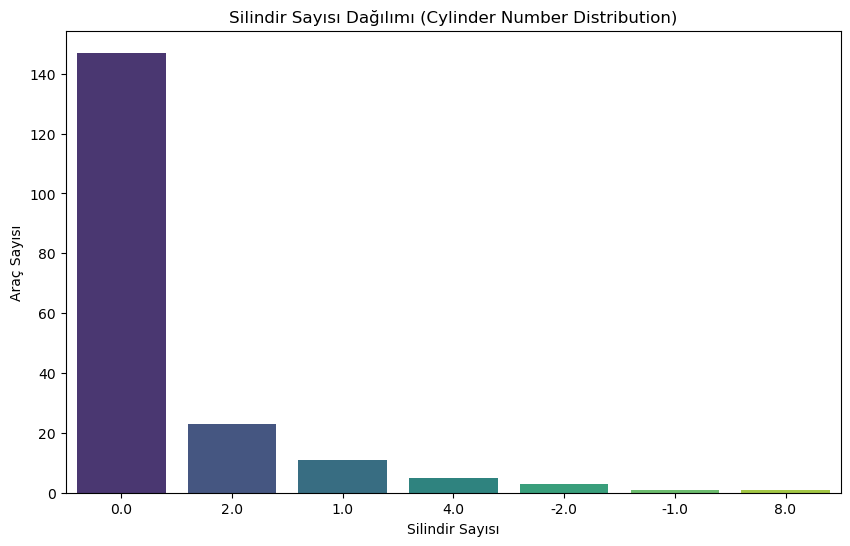

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sayısal Dağılım (Kaç tane 'four', kaç tane 'six' var?)
print("Silindir Sayısı Dağılımı:")
print(df['cylindernumber'].value_counts())

# 2. Yüzdesel Dağılım
print("\nYüzdesel Oranlar:")
print(df['cylindernumber'].value_counts(normalize=True) * 100)

# 3. Görsel Dağılım (Count Plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cylindernumber', order=df['cylindernumber'].value_counts().index, palette='viridis')
plt.title('Silindir Sayısı Dağılımı (Cylinder Number Distribution)')
plt.xlabel('Silindir Sayısı')
plt.ylabel('Araç Sayısı')
plt.show()

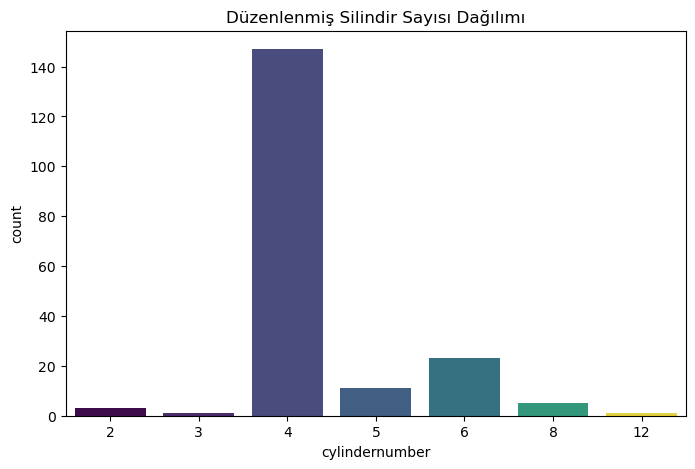

Veri tipi: int64


In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dağılımda gördüğümüz tüm değerleri kapsayan bir sözlük (mapping) oluşturalım
# Eğer değerlerin zaten sayıysa bu adımı atlayabilirsin, ama string (metin) ise mutlaka yapmalısın.
cylinder_mapping = {
    'four': 4,
    'six': 6,
    'five': 5,
    'eight': 8,
    'two': 2,
    'three': 3,
    'twelve': 12
}

# 2. Değişimi uygulayalım (Sütun metin tipindeyse sayıya çevirir)
# Eğer zaten sayısal görünüyorlarsa bile tipini 'int' yaparak garantiye alalım
if df['cylindernumber'].dtype == 'object':
    df['cylindernumber'] = df['cylindernumber'].map(cylinder_mapping)

# 3. Gelecekte hata almamak için grafiği güncelleyelim (Warning'siz hali)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cylindernumber', hue='cylindernumber', palette='viridis', legend=False)
plt.title('Düzenlenmiş Silindir Sayısı Dağılımı')
plt.show()

print("Veri tipi:", df['cylindernumber'].dtype)

In [75]:
from sklearn.preprocessing import RobustScaler

# 1. RobustScaler nesnesini oluşturalım
robust_scaler = RobustScaler()

# 2. cylindernumber sütununu ölçeklendir ve üzerine yaz
# fit_transform her zaman 2 boyutlu dizi bekler, bu yüzden [['...']] kullanıyoruz
df[['cylindernumber']] = robust_scaler.fit_transform(df[['cylindernumber']])

# 3. Sonuçları kontrol et
print("Ölçeklendirilmiş cylindernumber değerleri (İlk 5):")
print(df['cylindernumber'].head())

Ölçeklendirilmiş cylindernumber değerleri (İlk 5):
0    0.0
1    2.0
2    0.0
3    1.0
4    1.0
Name: cylindernumber, dtype: float64


In [76]:
df.head()

,aspiration,enginelocation,carwidth,curbweight,cylindernumber,stroke,peakrpm,price,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,0,0,-0.518519,-0.048068,0.0,-2.033333,-0.142857,expensive,True,False,False,False,False,False,False
1,0,0,0.000000,0.476395,2.0,0.600000,-0.142857,expensive,False,False,False,False,False,True,False
2,0,0,0.000000,-0.450474,0.0,0.366667,0.571429,expensive,False,False,False,True,False,False,False
3,0,0,0.333333,0.478302,1.0,0.366667,0.571429,expensive,False,False,False,True,False,False,False
4,0,0,0.296296,-0.126260,1.0,0.366667,0.571429,expensive,False,False,False,True,False,False,False


<details>
<summary><i>Ölçekleme ve encoding işlemlerinden sonra DataFrame’inizin nasıl görünmesi gerektiğine dair bir ekran görüntüsü aşağıdadır</i></summary>
    
    
<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/car_price_after_scaling_and_encoding.png">    

</details>

### `price`

👇 Hedef `price`ı kodlayın.

<details>
    <summary>💡 İpucu </summary>
    <br>
    ℹ️ <code>price</code> target değişkendir ve LabelEncoder ile encode edilmelidir.
</details>

In [78]:
from sklearn.preprocessing import LabelEncoder

# 1. LabelEncoder nesnesini oluşturalım
le = LabelEncoder()

# 2. price sütununu dönüştürelim
# Bu işlem "cheap" ve "expensive" değerlerini 0 ve 1'e çevirir
df['price'] = le.fit_transform(df['price'])

# 3. Hangi sayının hangi kategoriye denk geldiğini kontrol edelim
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Eşleşme Durumu: {mapping}")

# 4. Sonuçları görelim
print("\nPrice Sütunu (İlk 5 Satır):")
print(df['price'].head())

Eşleşme Durumu: {'cheap': 0, 'expensive': 1}

Price Sütunu (İlk 5 Satır):
0    1
1    1
2    1
3    1
4    1
Name: price, dtype: int32


🧪 **Kodunu test et**

In [79]:
from nbresult import ChallengeResult

result = ChallengeResult('encoding',
                         dataset = df)
result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0 -- c:\Users\nidat\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\nidat\.vscode\S16D2-S-Data-car-prices\tests
plugins: anyio-4.2.0
collecting ... collected 4 items

test_encoding.py::TestEncoding::test_aspiration PASSED                   [ 25%]
test_encoding.py::TestEncoding::test_enginelocation PASSED               [ 50%]
test_encoding.py::TestEncoding::test_enginetype PASSED                   [ 75%]
test_encoding.py::TestEncoding::test_price PASSED                        [100%]

============================== 4 passed in 2.62s ==============================


💯 You can commit your code:

git add tests/encoding.pickle

git commit -m 'Completed encoding step'

git push origin master



## (5) Temel Modelleme (Base Modelling)

👏 Veri kümesi ön işleme tabi tutuldu ve artık modele uyarlanmaya hazır. 

❓ **Soru: Bir classification modelini ilk kez değerlendirme** ❓

Ön işlenmiş bu dataset üzerinde bir `LogisticRegression` modeli için cross-validation çalıştırın ve elde edilen skoru `base_model_score` adlı değişkende saklayın.

In [68]:
# SENİN KODUN BURAYA

🧪 **Kodunu test et**

In [69]:
from nbresult import ChallengeResult

result = ChallengeResult('base_model',
                         score = base_model_score
)

result.write()
print(result.check())

NameError: name 'base_model_score' is not defined

## (6) Özellik Seçimi  (Feature Selection (with _Permutation Importance_))

👩🏻‍🏫 Bir feature’ın target’ı tahmin etmede gerçekten önemli olup olmadığını tespit etmenin güçlü bir yolu şudur:

1. Bir model çalıştırın ve skorunu ölçün  
2. Bu feature’ı karıştırın (shuffle edin), modeli tekrar çalıştırın ve skoru tekrar ölçün  
    - Eğer performans **belirgin şekilde düşerse**, bu feature önemlidir ve **çıkarılmamalıdır**
    - Eğer performans **çok fazla düşmezse**, bu feature **elenebilir**

❓ **Sorular** ❓

1. Modele en az bilgi katkısı sağlayan feature’ları tespit etmek için feature permutation uygulayın.
2. Model performansının belirgin şekilde düşmeye başladığını fark edene kadar zayıf feature’ları dataset’ten çıkarın.
3. Elde ettiğiniz yeni güçlü feature set’i ile yeni bir modeli cross-validation ile değerlendirin ve skorunu `strong_model_score` adlı değişkende saklayın.

In [ ]:
# SENİN KODUN BURAYA

🧪 **Kodunu test et**

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('strong_model',
                         score = strong_model_score
)

result.write()
print(result.check())

## Bonus -  Verilerinizi sınıflandırma (Stratifying your data) ⚖️

💡 Veriyi training ve testing olarak bölerken, dataset’imizdeki kategorik değişkenlerin oranına dikkat etmemiz gerekir — ister target `y`’nin sınıfları olsun ister `X` içindeki kategorik bir feature olsun.

Aşağıda bir örneğe bakalım 👇

❓ Orijinal `X` ve `y` verinizi sklearn’in `train_test_split` fonksiyonunu kullanarak training ve testing olarak ayırın; karşılaştırılabilir sonuçlar elde etmek için `random_state=1` ve `test_size=0.3` kullanın.

In [ ]:
# SENİN KODUN BURAYA

❓ Training dataset’inizde ve testing dataset’inizde `price` sınıfı **1** olan araçların oranını kontrol edin.

> _Ham `df` içinde bu orana baktığınızda, yaklaşık **%50 / %50** olması gerekir._

In [ ]:
# SENİN KODUN BURAYA

☝️ Hâlâ yaklaşık olarak **%50 / %50** civarında olmalı.

***Peki random state’i değiştirirsek ne olur?***

❓ `random_state` değerlerini **1’den 10’a** kadar döngüye alın ve her seferinde training ve testing dataset’lerindeki `price` sınıfı **1** olan araçların oranını hesaplayın. ❓

In [ ]:
# SENİN KODUN BURAYA

Her seferinde oranların değiştiğini, hatta bazen oldukça ciddi şekilde değiştiğini gözlemleyeceksiniz 😱! Bu durum model performansını etkileyebilir.

❓ `train_test_split(random_state=1)` kullanılarak eğitilen bir Logistic Regression modelinin test skorunu,  
`random_state=9` kullanılarak eğitilen modelin test skoru ile karşılaştırın ❓

Eğitimi training data üzerinde yapmayı ve skoru testing data üzerinde hesaplamayı unutmayın.

In [ ]:
# SENİN KODUN BURAYA

👀 `random_state=9` ile çok daha düşük bir skor görmelisiniz; çünkü bu test setindeki sınıf **1** araçların oranı %34.5 iken, training setinde bu oran %57.9’a, hatta orijinal dataset’te yaklaşık %50’ye yakındır.

Bu durum oldukça önemlidir; çünkü dataset’te oluşan bu **rastlantısal dengesizlik**, yalnızca model performansını düşürmekle kalmaz, aynı zamanda eğitim veya değerlendirme sırasında “gerçekliği” de bozabilir 🧐

***Peki bu sorunu nasıl çözebiliriz? Tren seti ve test seti arasında sınıfların dağılımını nasıl aynı tutabiliriz? 🔧***

🎁 Neyse ki sklearn’de, estimator (yani model) bir classifier olduğunda ve target bir sınıf olduğunda, bu durum `cross_validate` tarafından otomatik olarak ele alınır. 📚 [**sklearn.model_selection.cross_validate**](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) dokümantasyonunda `cv` parametresini inceleyin.

Çözüm, aşağıdakini kullanmaktır:

> 📚 [**Stratification (Katmanlama)**](https://scikit-learn.org/stable/modules/cross_validation.html#stratification)

### Hedefin tabakalaşması (Stratification of the target)

💡 ***Stratification*** tekniğini `train_test_split` içinde de kullanabiliriz.

❓ Bu kez **1’den 10’a** kadar olan `random_state` döngüsünü tekrar çalıştırın, ancak bu sefer holdout yöntemine ***`stratify=y`*** parametresini de ekleyin. ❓

In [ ]:
# SENİN KODUN BURAYA

👀 Random state değişse bile, training ve testing verilerindeki sınıf oranları, orijinal `y` içindeki oranlarla aynı tutulur. İşte _stratification_ (katmanlama) tam olarak budur.

`train_test_split` fonksiyonunu `stratify` parametresiyle kullandığımızda, training ve testing verileri arasında **bir feature’ın oranlarını da koruyabiliriz**. Bu, özellikle aşağıdaki durumlarda son derece önemlidir:

- Churn tahmininde erkek ve kadın müşteri oranlarını korumak 🙋‍♂️ 🙋
- Ev fiyatlarını tahmin ederken büyük ve küçük evlerin oranlarını korumak 🏠 🏰
- Bir sonraki ürünü önerirken 1–5 arası review score dağılımını (multiclass!) korumak 🛍️
- vb.

Örneğin, bizim dataset’imizde `aspiration` feature’ının training ve testing verilerinde aynı oranda kalmasını istiyorsak, şu şekilde yazabiliriz:

`train_test_split(X, y, test_size=0.3, stratify=X.aspiration)`

---

Gördüğümüz gibi, **`cross_validate` [target değişkeni otomatik olarak stratify edebilir](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#:~:text=For%20int/None%20inputs%2C%20if%20the%20estimator%20is%20a%20classifier%20and%20y%20is%20either%20binary%20or%20multiclass%2C%20StratifiedKFold%20is%20used.)**, ancak **feature’lar için bunu yapmaz** 🤔 Bunun için biraz ekstra çalışmaya ihtiyacımız var.

Bunun için `StratifiedKFold` kullanmamız gerekiyor 🔬

### Tabakalaşma (Stratification - generalized)

📚 [**StratifiedKFold**](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html), veriyi `K` parçaya bölerken belirli sütunlar (feature veya target) üzerinden stratification yapmamıza olanak tanır.

Bu sayede, ilgilendiğimiz kategorik feature’ların oranlarını koruyarak manuel bir cross-validation yapabiliriz — bunu ikili (binary) `aspiration` feature’ı ile deneyelim:

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Veriyi 5 fold’a bölecek bir stratified k-fold oluşturma
skf = StratifiedKFold(n_splits=5)
scores = []

# .split() metodu bir iterator oluşturur; 'X.aspiration' stratify edeceğimiz feature’dır
for train_indices, test_indices in skf.split(X, X.aspiration):

    # 'train_indices' ve 'test_indices', orantılı bölünmeler üreten indeks listeleridir
    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    # modeli başlatma ve eğitme
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # en sonunda 5 fold’un ortalamasını almak için skoru listeye ekleme
    scores.append(model.score(X_test, y_test))

np.array(scores).mean()

📚 [**StratifiedKFold**](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html), veriyi `K` parçaya bölerken belirli sütunlar (feature veya target) üzerinden stratification yapmamıza olanak tanır.

Bu sayede, ilgilendiğimiz kategorik feature’ların oranlarını koruyarak manuel bir cross-validation yapabiliriz — bunu ikili (binary) `aspiration` feature’ı ile deneyelim:


🏁 Tebrikler! Tüm veri setini hazırladınız, özellik seçimi yaptınız ve hatta tabakalaşma hakkında bilgi edindiniz 💪.

💾 Not defterinizi git add/commit/push yapmayı unutmayın...

🚀 ... ve bir sonraki challenge'a geçin!